In [54]:
#Importing libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#setting a visual style
sns.set_theme(style="whitegrid",palette="muted")

In [55]:
# Loading the dataset and checking its structure

df = pd.read_csv('zomato.csv')
print("--- Dataset Info ---")
df.shift()


--- Dataset Info ---


,Restaurant_ID,City,Cuisines,Average_Cost_for_two,Has_Online_delivery,Aggregate_Rating,Votes,Price_Range
0,None,None,None,NaN,None,NaN,NaN,NaN
1,ZOM_1,Pune,Fast Food,220.0,Yes,NaN,3690.0,1.0
2,ZOM_2,Hyderabad,Fast Food,1020.0,No,2.2,4043.0,2.0
3,ZOM_3,Bangalore,Continental,1120.0,Yes,2.8,2485.0,1.0
4,ZOM_4,Hyderabad,Chinese,1440.0,No,3.8,3316.0,4.0
...,...,...,...,...,...,...,...,...
19995,ZOM_19995,Hyderabad,Italian,710.0,Yes,2.4,3393.0,1.0
19996,ZOM_19996,Mumbai,Chinese,870.0,Yes,4.5,3948.0,1.0
19997,ZOM_19997,Bangalore,Italian,550.0,No,2.8,398.0,1.0
19998,ZOM_19998,Mumbai,Continental,950.0,Yes,2.8,718.0,3.0


In [56]:
# Phase 1 - Task 1: Identify Data Types (Numerical vs Categorical)
# Separating columns into numerical and categorical
print("=== Column Data Types: Numerical vs Categorical ===\n")

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Columns ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"{col} — {df[col].dtype}")

print(f"\nCategorical Columns ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f" {col} — {df[col].dtype} ")

=== Column Data Types: Numerical vs Categorical ===

Numerical Columns (4):
Average_Cost_for_two — float64
Aggregate_Rating — float64
Votes — int64
Price_Range — int64

Categorical Columns (4):
 Restaurant_ID — object 
 City — object 
 Cuisines — object 
 Has_Online_delivery — object 


In [57]:
# Phase 1 - Task 2: Descriptive Statistics for Average_Cost_for_two
# Calculating basic statistics for cost column
# Mean tells us the average, median the middle value, mode the most common value
mean   = df['Average_Cost_for_two'].mean()
median = df['Average_Cost_for_two'].median()
mode   = df['Average_Cost_for_two'].mode()[0]

print("=== Descriptive Statistics: Average Cost for Two ===")
print(f"  Mean   : ₹{mean:.2f}")
print(f"  Median : ₹{median:.2f}")
print(f"  Mode   : ₹{mode:.2f}")

=== Descriptive Statistics: Average Cost for Two ===
  Mean   : ₹835.51
  Median : ₹670.00
  Mode   : ₹410.00


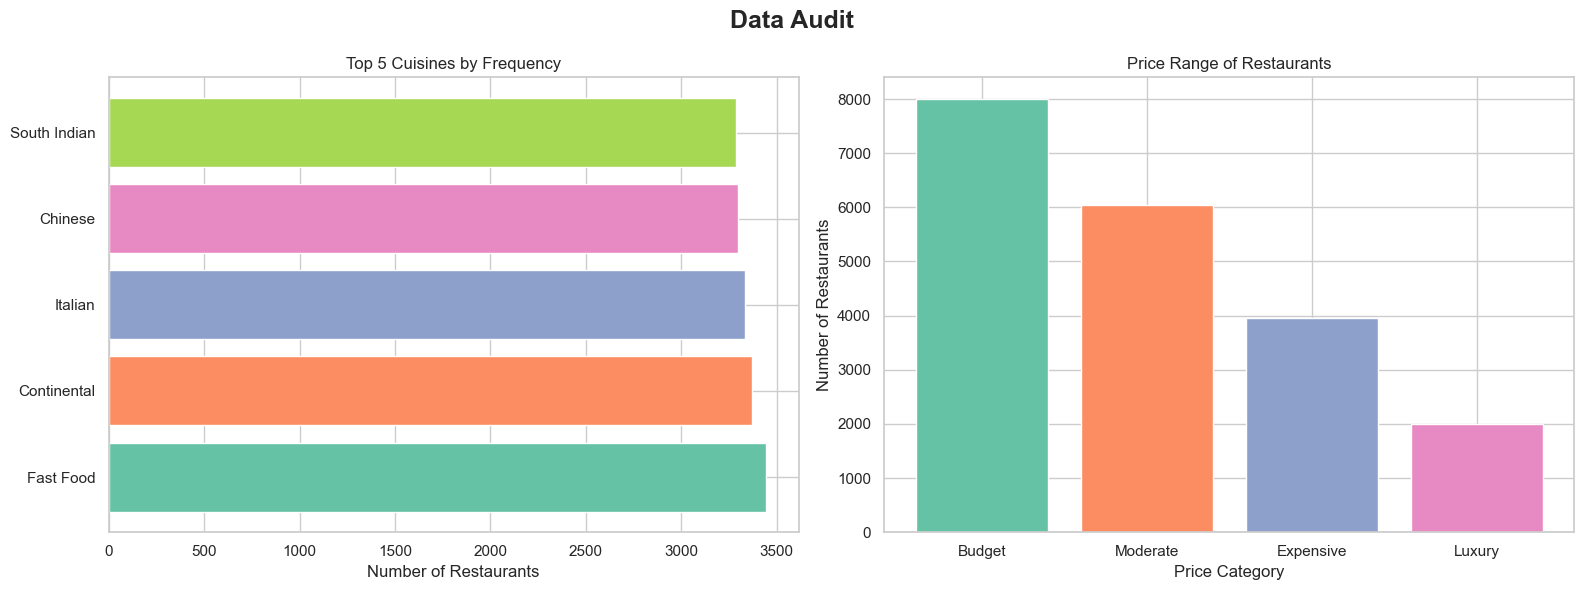

In [58]:
# Phase 1 - Data Audit: Top 5 Cuisines & Price Range
# Visualizing top 5 cuisines and price distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 5 Cuisines
top5 = df['Cuisines'].value_counts().head(5)
axes[0].barh(top5.index, top5.values, color=sns.color_palette("Set2", 5))
axes[0].set_title("Top 5 Cuisines by Frequency")
axes[0].set_xlabel("Number of Restaurants")

# Price Range
price_counts = df['Price_Range'].value_counts().sort_index()
price_counts.index = ['Budget', 'Moderate', 'Expensive', 'Luxury']
axes[1].bar(price_counts.index, price_counts.values, color=sns.color_palette("Set2", 4))
axes[1].set_title("Price Range of Restaurants")
axes[1].set_xlabel("Price Category")
axes[1].set_ylabel("Number of Restaurants")

plt.suptitle("Data Audit", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
# Phase 2 - Snapshot of Messy Data (Before Cleaning)
# Checking the raw data before we clean it
print("=== RAW DATA AUDIT - Before Cleaning ===\n")

# Missing Values
print("1. Missing Values:")
print(df.isnull().sum())

# Duplicate Rows
print(f"\n2. Duplicate Rows: {df.duplicated().sum()}")

# Unique values in categorical columns
print(f"\n3. Has_Online_delivery unique values: {df['Has_Online_delivery'].unique()}")

# Outlier preview
print(f"\n4. Average_Cost_for_two - Min: ₹{df['Average_Cost_for_two'].min()} | Max: ₹{df['Average_Cost_for_two'].max()}")
print(f"   Huge gap suggests outliers exist!")

# Sample of raw data
print("\n5. Sample of Raw Data:")
df.head()

=== RAW DATA AUDIT - Before Cleaning ===

1. Missing Values:
Restaurant_ID              0
City                       0
Cuisines                   0
Average_Cost_for_two       0
Has_Online_delivery        0
Aggregate_Rating        1200
Votes                      0
Price_Range                0
dtype: int64

2. Duplicate Rows: 0

3. Has_Online_delivery unique values: ['Yes' 'No']

4. Average_Cost_for_two - Min: ₹70.0 | Max: ₹50000.0
   Huge gap suggests outliers exist!

5. Sample of Raw Data:


,Restaurant_ID,City,Cuisines,Average_Cost_for_two,Has_Online_delivery,Aggregate_Rating,Votes,Price_Range
0,ZOM_1,Pune,Fast Food,220.0,Yes,NaN,3690,1
1,ZOM_2,Hyderabad,Fast Food,1020.0,No,2.2,4043,2
2,ZOM_3,Bangalore,Continental,1120.0,Yes,2.8,2485,1
3,ZOM_4,Hyderabad,Chinese,1440.0,No,3.8,3316,4
4,ZOM_5,Hyderabad,Chinese,1370.0,No,NaN,1838,2


In [60]:
#  Detect Missing Values ---
# Phase 2 - Task 1: Imputation 
print("Missing values before imputation:", df['Aggregate_Rating'].isnull().sum())

# Fill missing ratings with the average rating of that specific city
df['Aggregate_Rating'] = df['Aggregate_Rating'].fillna(
    df.groupby('City')['Aggregate_Rating'].transform('mean')
)

print("Missing values after imputation:", df['Aggregate_Rating'].isnull().sum())



Missing values before imputation: 1200
Missing values after imputation: 0


In [61]:
# Convert Has Online delivery into Binary (1/0)
# Converting (Yes/No) text into (1/0) numbers
df['Has_Online_delivery'] = df['Has_Online_delivery'].map({'Yes': 1, 'No': 0})

print("Converted Full Column:")
print(df['Has_Online_delivery'])

Converted Full Column:
0        1
1        0
2        1
3        0
4        0
        ..
19995    1
19996    0
19997    1
19998    1
19999    0
Name: Has_Online_delivery, Length: 20000, dtype: int64


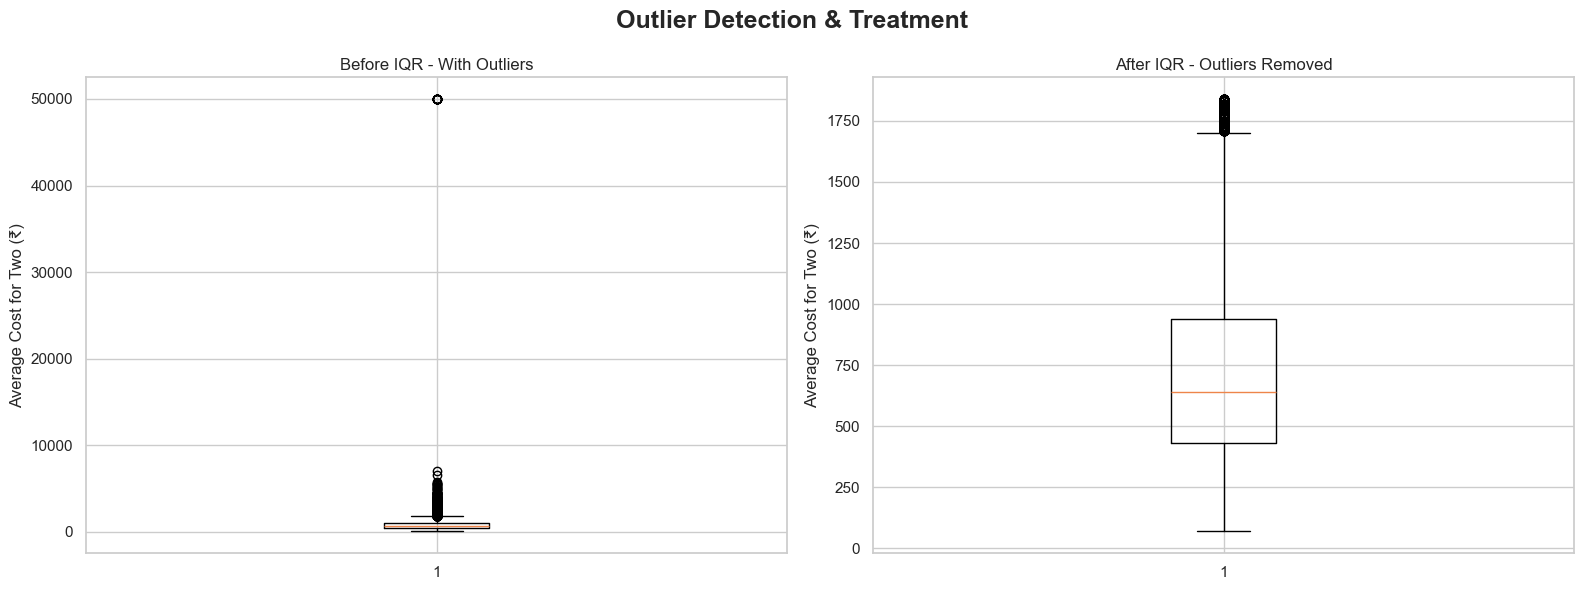

Lower Bound: ₹-400.00
Upper Bound: ₹1840.00
Rows remaining after IQR: 19094


In [62]:
# Phase 2 - Boxplot Before & After IQR
# Removing extreme values using IQR method
# Visualizing outliers before and after removing them
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before IQR
axes[0].boxplot(df['Average_Cost_for_two'])
axes[0].set_title("Before IQR - With Outliers")
axes[0].set_ylabel("Average Cost for Two (₹)")

# Apply IQR
Q1 = df['Average_Cost_for_two'].quantile(0.25)
Q3 = df['Average_Cost_for_two'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Average_Cost_for_two'] >= lower_bound) & 
        (df['Average_Cost_for_two'] <= upper_bound)]

# After IQR
axes[1].boxplot(df['Average_Cost_for_two'])
axes[1].set_title("After IQR - Outliers Removed")
axes[1].set_ylabel("Average Cost for Two (₹)")

plt.suptitle("Outlier Detection & Treatment", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Lower Bound: ₹{lower_bound:.2f}")
print(f"Upper Bound: ₹{upper_bound:.2f}")
print(f"Rows remaining after IQR: {len(df)}")

In [63]:
# Phase 2 - Task 3: Normalization
# Using Min-Max scaling to bring cost values into a common 0–1 range
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Average_Cost_Normalized'] = scaler.fit_transform(df[['Average_Cost_for_two']])

print("=== Before & After Normalization ===")
print(df[['Average_Cost_for_two', 'Average_Cost_Normalized']].head(10))

=== Before & After Normalization ===
    Average_Cost_for_two  Average_Cost_Normalized
0                  220.0                 0.084746
1                 1020.0                 0.536723
2                 1120.0                 0.593220
3                 1440.0                 0.774011
4                 1370.0                 0.734463
6                  850.0                 0.440678
7                 1210.0                 0.644068
8                  670.0                 0.338983
9                  410.0                 0.192090
10                1020.0                 0.536723


Correlation between Votes and Aggregate_Rating: 0.0009


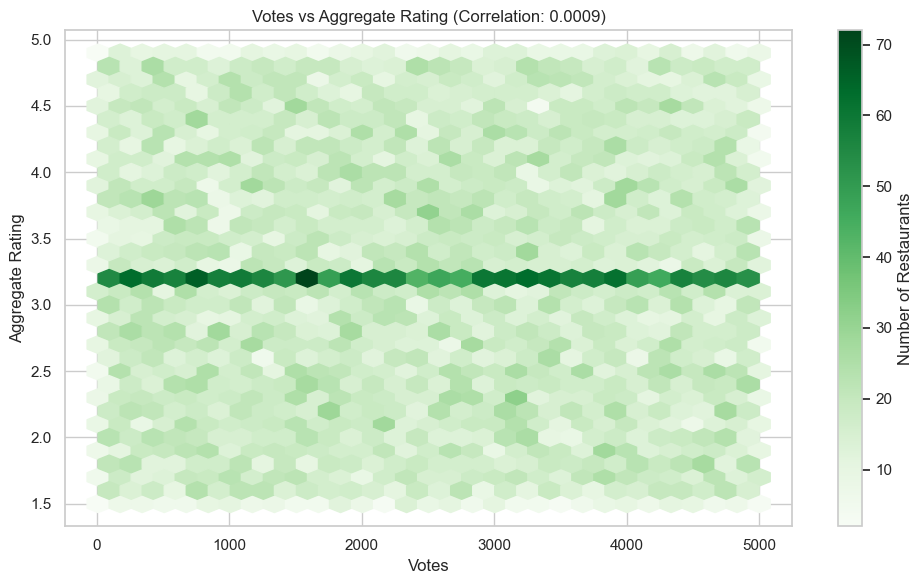

In [64]:
# Finding the correlation to understand the relationship
# between number of votes and aggregate rating
correlation = df['Votes'].corr(df['Aggregate_Rating'])
print(f"Correlation between Votes and Aggregate_Rating: {correlation:.4f}")

# Using hexbin plot to visualize dense data points
# and reduce overlap seen in scatter plots
plt.figure(figsize=(10, 6))
plt.hexbin(df['Votes'], df['Aggregate_Rating'], gridsize=30, cmap='Greens')
plt.colorbar(label='Number of Restaurants')
plt.title(f"Votes vs Aggregate Rating (Correlation: {correlation:.4f})")
plt.xlabel("Votes") 
plt.ylabel("Aggregate Rating")
plt.tight_layout()
plt.show()

In [65]:
# CONCLUSION: Correlation = 0.0009 (Near Zero)
# Votes and Ratings are independent of each other.
# Popularity does not guarantee quality on Zomato.



In [66]:
# Calculating the probability of a restaurant having
# rating above 4.0 when online delivery is available

# Restaurants offering online delivery
has_delivery = df[df['Has_Online_delivery'] == 1]

# Restaurants with online delivery and high ratings
delivery_and_high_rating = df[
    (df['Has_Online_delivery'] == 1) & (df['Aggregate_Rating'] > 4.0)
]

# Conditional probability calculation
prob = len(delivery_and_high_rating) / len(has_delivery)

print("=== Conditional Probability ===")
print(f"Total restaurants with Online Delivery: {len(has_delivery)}")
print(f"Restaurants with Online Delivery AND Rating > 4.0: {len(delivery_and_high_rating)}")
print(f"\nP(Rating > 4.0 | Online Delivery) = {prob:.4f} = {prob*100:.2f}%")

=== Conditional Probability ===
Total restaurants with Online Delivery: 12339
Restaurants with Online Delivery AND Rating > 4.0: 2899

P(Rating > 4.0 | Online Delivery) = 0.2349 = 23.49%


In [67]:
# CONCLUSION: 23.49% probability
# Only 23 out of 100 delivery restaurants have rating > 4.0
# Online delivery is not a success guarantee — quality drives ratings!

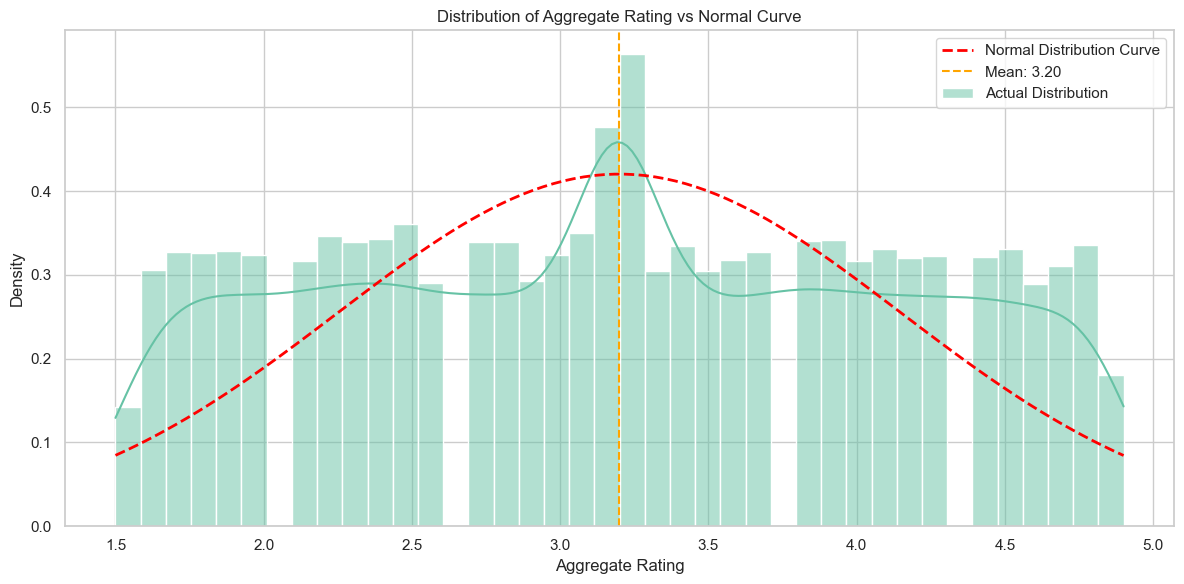

Mean Rating  : 3.20
Std Deviation: 0.95
Skewness     : 0.0140


In [68]:
# Phase 3 - Task 3: Distribution of Aggregate_Rating with Normal Distribution Curve

from scipy import stats
import numpy as np

plt.figure(figsize=(12, 6))

# Plot actual data distribution as histogram with KDE
sns.histplot(df['Aggregate_Rating'], bins=40, kde=True, color=sns.color_palette("Set2")[0], stat='density', label='Actual Distribution')

# Calculate mean & std, then generate normal curve for comparison
mean = df['Aggregate_Rating'].mean()
std = df['Aggregate_Rating'].std()
x = np.linspace(df['Aggregate_Rating'].min(), df['Aggregate_Rating'].max(), 100)
normal_curve = stats.norm.pdf(x, mean, std)  # Theoretical normal distribution

# Overlay normal curve and mean line
plt.plot(x, normal_curve, color='red', linewidth=2, linestyle='--', label='Normal Distribution Curve')
plt.axvline(mean, color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.2f}')

plt.title("Distribution of Aggregate Rating vs Normal Curve")
plt.xlabel("Aggregate Rating")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Print stats — skewness near 0 = normal, >0 = right skewed, <0 = left skewed
print(f"Mean Rating  : {mean:.2f}")
print(f"Std Deviation: {std:.2f}")
print(f"Skewness     : {df['Aggregate_Rating'].skew():.4f}")

In [69]:
# CONCLUSION: Ratings are uniformly distributed (NOT a normal bell curve)
# No inflationary bias — high and low ratings are equally common
# Mean rating = 3.20 — the average Zomato restaurant is just "average"

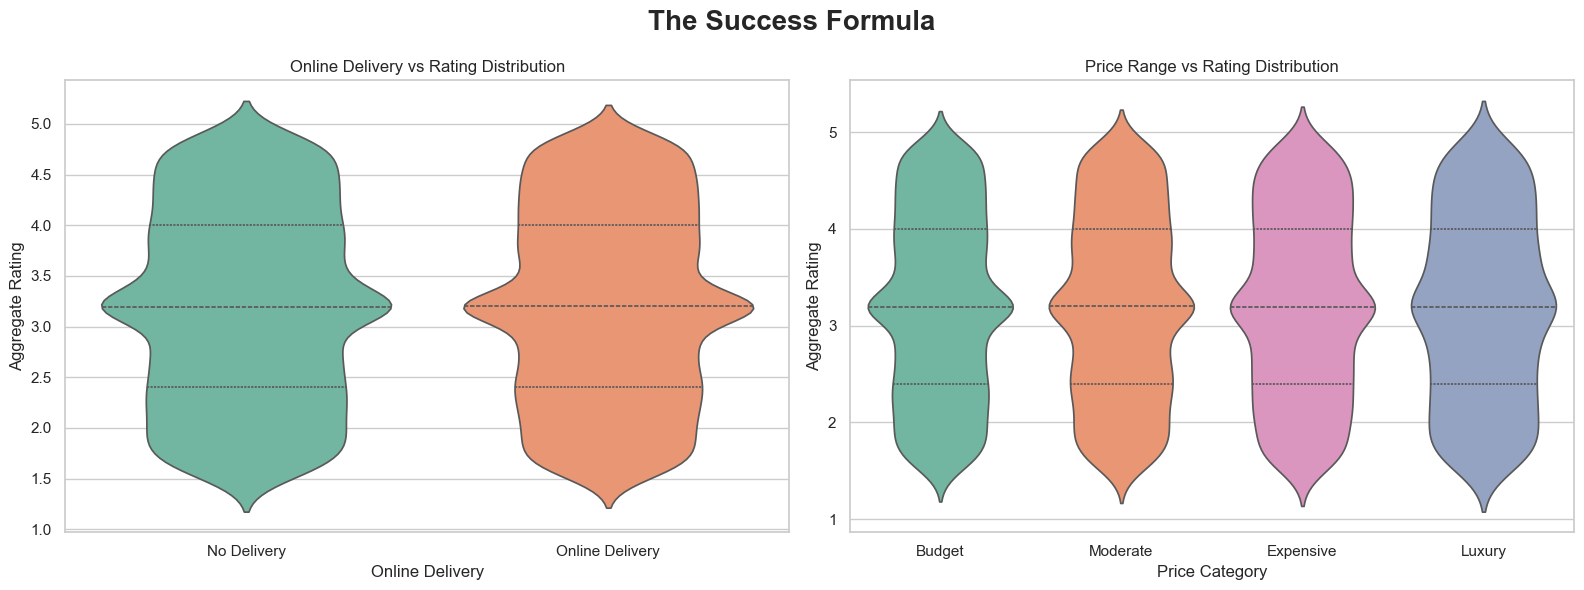

In [70]:
# Phase 3 - Deliverable: The Success Formula (Violin Plot)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Online Delivery vs Rating ---
# Violin plot shows rating distribution for restaurants with/without online delivery
sns.violinplot(x='Has_Online_delivery', y='Aggregate_Rating',
               hue='Has_Online_delivery',
               data=df, palette="Set2", ax=axes[0], inner='quartile', legend=False)
# inner='quartile' shows median and IQR lines inside the violin

axes[0].set_title("Online Delivery vs Rating Distribution")
axes[0].set_xlabel("Online Delivery")
axes[0].set_ylabel("Aggregate Rating")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Delivery', 'Online Delivery'])  # Rename 0/1 to readable labels

# --- Plot 2: Price Range vs Rating ---
# Map numeric price range to readable labels
df['Price_Label'] = df['Price_Range'].map({1:'Budget', 2:'Moderate', 3:'Expensive', 4:'Luxury'})

sns.violinplot(x='Price_Label', y='Aggregate_Rating',
               hue='Price_Label',
               data=df, palette="Set2", ax=axes[1], inner='quartile',
               order=['Budget', 'Moderate', 'Expensive', 'Luxury'], legend=False)
# order= ensures categories appear low→high price, not alphabetically

axes[1].set_title("Price Range vs Rating Distribution")
axes[1].set_xlabel("Price Category")
axes[1].set_ylabel("Aggregate Rating")

plt.suptitle("The Success Formula", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
# === CONCLUSION: The Success Formula ===

# 1. Online Delivery Impact:
#    - No Delivery avg rating  : 3.19
#    - With Delivery avg rating : 3.20
#    - Difference = only 0.01 → Online Delivery has NEGLIGIBLE impact on ratings

# 2. Price Range Impact:
#    - Budget to Luxury difference = ~0.02 → Price also has NEGLIGIBLE impact

# 3. VERDICT:
#    Neither online delivery nor price point significantly affects ratings!
#    The violin shapes are almost identical across all groups.
#    This tells us that FOOD QUALITY & SERVICE is what truly drives ratings —
#    not whether you offer delivery or how expensive you are.

# 4. Business Advice:
#    A new restaurant owner should NOT rely on:
#     Just adding online delivery to get better ratings
#     Charging more to seem "premium"
#     Instead — focus on FOOD QUALITY and CUSTOMER EXPERIENCE!

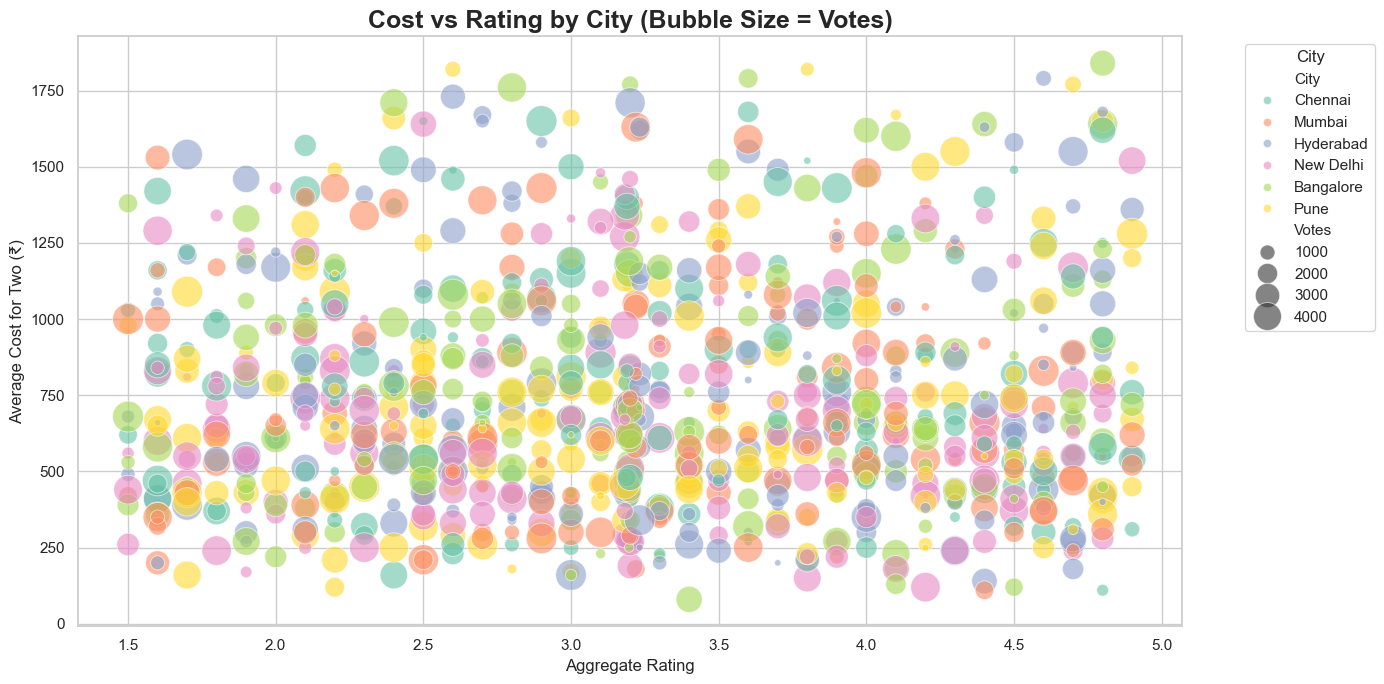

In [72]:
# Phase 4 - Task 1: Bivariate Analysis - Cost vs Rating (Bubble Chart)
plt.figure(figsize=(14, 7))
# Bubble chart: each point = 1 restaurant
# x = Rating, y = Cost, color = City, bubble size = Votes
sns.scatterplot(x='Aggregate_Rating', y='Average_Cost_for_two',
                hue='City', size='Votes',
                data=df.sample(1000, random_state=42),
                alpha=0.6, palette="Set2",
                sizes=(20, 500))

plt.title("Cost vs Rating by City (Bubble Size = Votes)", fontsize=18, fontweight='bold')
plt.xlabel("Aggregate Rating")
plt.ylabel("Average Cost for Two (₹)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='City')
plt.tight_layout()
plt.show()

In [73]:
# === CONCLUSION: Cost vs Rating by City (Bubble Chart) ===

# 1. Cost & Rating Relationship:
#    - No clear pattern between cost and rating
#    - Expensive restaurants (₹4000+) don't always have higher ratings
#    - Budget restaurants can also achieve high ratings

# 2. City Observations:
#    - All cities (Mumbai, Chennai, New Delhi etc.) are spread
#      across all price ranges — no city dominates a specific price point
#    - Every city has both budget and luxury restaurants

# 3. Bubble Size (Votes):
#    - Larger bubbles are mostly in the mid-price range (₹1000-₹3000)
#    - Most popular restaurants are NOT the most expensive ones
#    - Luxury restaurants (₹5000+) have smaller bubbles = less popular

# 4. VERDICT:
#    Sweet spot for a new restaurant = Mid price range (₹1000-₹3000)
#    This range attracts the most customers (votes)
#    Going luxury doesn't guarantee popularity or higher ratings

In [74]:
#"The most popular and well-rated restaurants are in the mid-price range — not the cheapest, not the most expensive!"

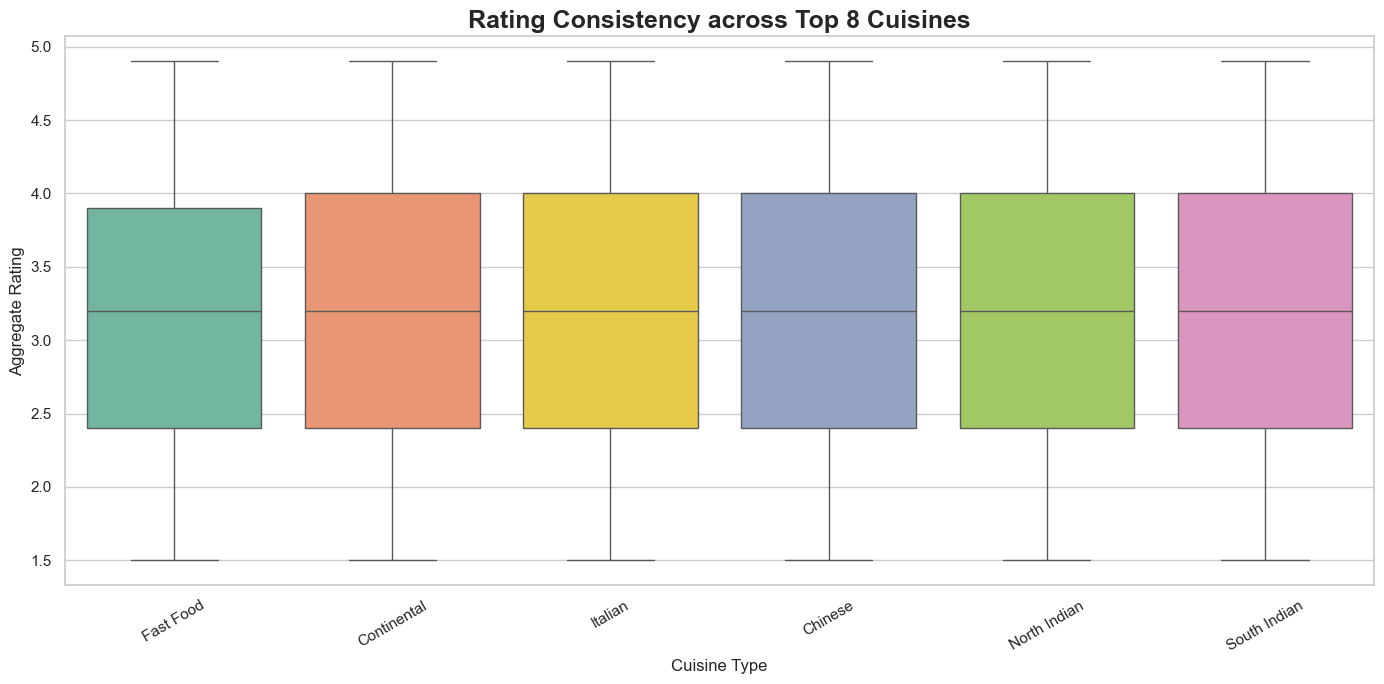

=== Cuisine Consistency (Lower std = More Consistent) ===
Cuisines
Chinese         0.942422
Fast Food       0.945391
South Indian    0.946019
Continental     0.947748
Italian         0.955631
North Indian    0.957117
Name: Aggregate_Rating, dtype: float64

Most Consistent Cuisine : Chinese
Least Consistent Cuisine: North Indian


In [75]:
# Phase 4 - Task 2: Boxplots - Ratings across Cuisine Types

# Get the top 8 most common cuisines and filter the dataframe
top8_cuisines = df['Cuisines'].value_counts().head(8).index
df_top_cuisines = df[df['Cuisines'].isin(top8_cuisines)]

plt.figure(figsize=(14, 7))

# Boxplot: each box shows min, Q1, median, Q3, max of ratings per cuisine
# Smaller box = more consistent ratings (less spread)
sns.boxplot(x='Cuisines', y='Aggregate_Rating',
            hue='Cuisines',
            data=df_top_cuisines, palette="Set2",
            order=top8_cuisines, legend=False)

plt.title("Rating Consistency across Top 8 Cuisines", fontsize=18, fontweight='bold')
plt.xlabel("Cuisine Type")
plt.ylabel("Aggregate Rating")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Measure consistency using std deviation — lower std = more consistent ratings
consistency = df_top_cuisines.groupby('Cuisines')['Aggregate_Rating'].std().sort_values()

print("=== Cuisine Consistency (Lower std = More Consistent) ===")
print(consistency)
print(f"\nMost Consistent Cuisine : {consistency.index[0]}")   
print(f"Least Consistent Cuisine: {consistency.index[-1]}")   

In [76]:
# === CONCLUSION: Cuisine Consistency ===

# 1. Most Consistent Cuisine: CHINESE (std = 0.942)
#    - Customers always know what to expect
#    - Reliable and predictable dining experience

# 2. Least Consistent Cuisine: NORTH INDIAN (std = 0.957)
#    - Most hit or miss cuisine
#    - Some restaurants are excellent, others are poor

# 3. Overall Observation:
#    - All cuisines have median rating around 3.2
#    - All boxes look similar in size — meaning NO cuisine
#      is dramatically more consistent than others
#    - The std difference between Chinese (0.942) and
#      North Indian (0.957) is very small = 0.015

# 4. VERDICT:
#    Chinese cuisine is the safest bet for consistency
#    All cuisines perform similarly on average
#    North Indian is riskiest — highest variance in quality

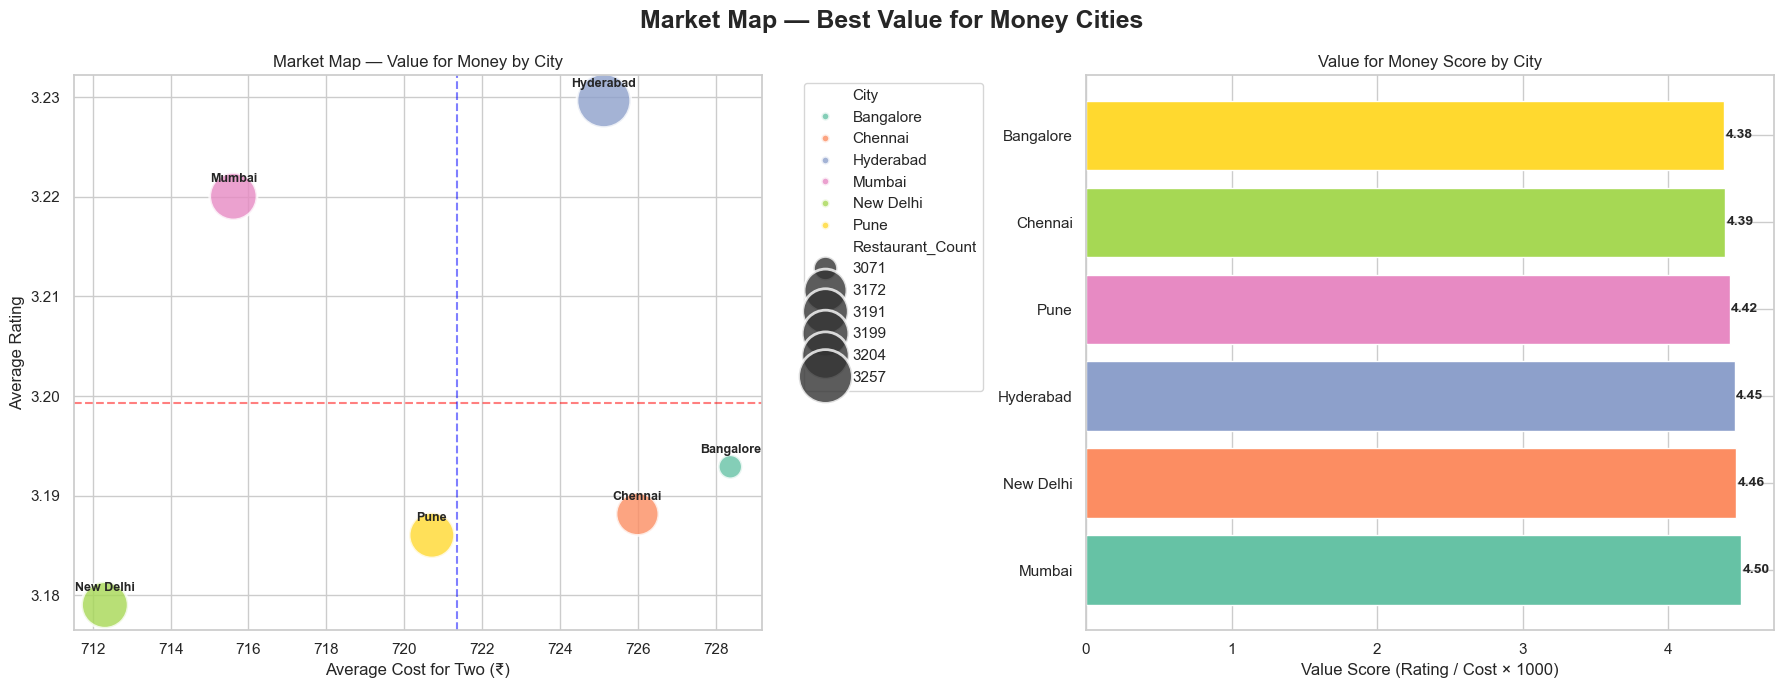

=== Value for Money Rankings ===
     City  Avg_Rating   Avg_Cost  Value_Score
   Mumbai    3.220038 715.611735     4.499700
New Delhi    3.179047 712.316349     4.462971
Hyderabad    3.229637 725.112066     4.453984
     Pune    3.186039 720.701974     4.420743
  Chennai    3.188171 725.974149     4.391576
Bangalore    3.192908 728.355585     4.383722


In [81]:
# Phase 4 - Deliverable: Market Map - Fixed
city_stats = df.groupby('City').agg(
    Avg_Rating=('Aggregate_Rating', 'mean'),
    Avg_Cost=('Average_Cost_for_two', 'mean'),
    Restaurant_Count=('Restaurant_ID', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Market Map Bubble Chart ---
sns.scatterplot(x='Avg_Cost', y='Avg_Rating',
                hue='City', size='Restaurant_Count',
                data=city_stats, palette="Set2",
                sizes=(300, 1500), alpha=0.8, ax=axes[0])

for i, row in city_stats.iterrows():
    axes[0].annotate(row['City'], 
                     (row['Avg_Cost'], row['Avg_Rating']),
                     textcoords="offset points", xytext=(0, 10),
                     fontsize=9, fontweight='bold', ha='center')

axes[0].axhline(city_stats['Avg_Rating'].mean(), color='red', linestyle='--', alpha=0.5)
axes[0].axvline(city_stats['Avg_Cost'].mean(), color='blue', linestyle='--', alpha=0.5)
axes[0].set_title("Market Map — Value for Money by City")
axes[0].set_xlabel("Average Cost for Two (₹)")
axes[0].set_ylabel("Average Rating")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Plot 2: Value Score Bar Chart ---
city_stats['Value_Score'] = city_stats['Avg_Rating'] / city_stats['Avg_Cost'] * 1000
city_stats_sorted = city_stats.sort_values('Value_Score', ascending=False)

bars = axes[1].barh(city_stats_sorted['City'], 
                     city_stats_sorted['Value_Score'],
                     color=sns.color_palette("Set2", len(city_stats)))
axes[1].set_title("Value for Money Score by City")
axes[1].set_xlabel("Value Score (Rating / Cost × 1000)")
for bar, val in zip(bars, city_stats_sorted['Value_Score']):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle("Market Map — Best Value for Money Cities", 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Value for Money Rankings ===")
print(city_stats_sorted[['City', 'Avg_Rating', 'Avg_Cost', 'Value_Score']].to_string(index=False))

In [ ]:
# === CONCLUSION: Market Map — Best Value for Money Cities ===

# Value Score = Avg_Rating / Avg_Cost × 1000

# RANKINGS:
# 1st - Mumbai    : Score 4.50 | Rating 3.22 | Cost ₹715
# 2nd - New Delhi : Score 4.46 | Rating 3.18 | Cost ₹712
# 3rd - Hyderabad : Score 4.45 | Rating 3.23 | Cost ₹725
# 4th - Pune      : Score 4.42 | Rating 3.19 | Cost ₹720
# 5th - Chennai   : Score 4.39 | Rating 3.19 | Cost ₹725
# 6th - Bangalore : Score 4.38 | Rating 3.19 | Cost ₹728

# 1. BEST VALUE: MUMBAI (4.50)
#    - Best combination of high rating + low cost
#    - Most restaurants to choose from

# 2. BEST RATED: HYDERABAD (3.23)
#    - Highest food quality but costs more

# 3. MOST EXPENSIVE: BANGALORE (₹728)
#    - Highest cost but average rating = Overpriced

# 4. VERDICT:
#    Open a restaurant in MUMBAI for best value market
#    Target HYDERABAD for premium quality positioning
#    Avoid BANGALORE — high costs, average ratings

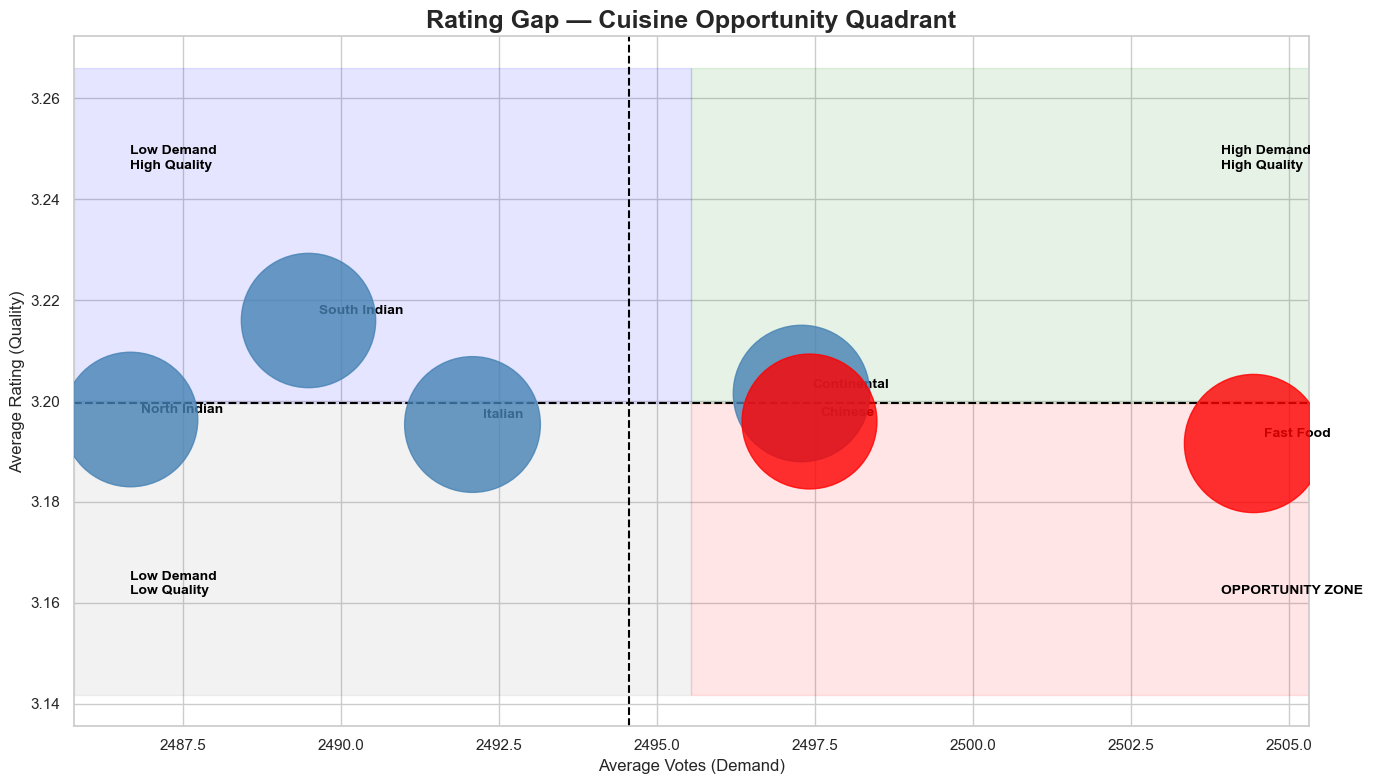

In [77]:
# Phase 5 - Task 1: Rating Gap - Quadrant Chart
# grouping by cuisine to get average rating, votes, and how many restaurants offer it
cuisine_stats = df.groupby('Cuisines').agg(
    Avg_Rating=('Aggregate_Rating', 'mean'),
    Avg_Votes=('Votes', 'mean'),
    Restaurant_Count=('Restaurant_ID', 'count')
).reset_index()

# keeping only top 12 cuisines by restaurant count so the chart stays readable
cuisine_stats = cuisine_stats.nlargest(12, 'Restaurant_Count')

# these will be our dividing lines in the chart
avg_votes = cuisine_stats['Avg_Votes'].mean()
avg_rating = cuisine_stats['Avg_Rating'].mean()

plt.figure(figsize=(14, 8))

# coloring each quadrant differently so its easy to tell which zone a cuisine falls in
plt.axhspan(avg_rating, cuisine_stats['Avg_Rating'].max() + 0.05,
            xmin=0, xmax=0.5, alpha=0.1, color='blue')    # Top Left  - Low Demand, High Quality
plt.axhspan(avg_rating, cuisine_stats['Avg_Rating'].max() + 0.05,
            xmin=0.5, xmax=1, alpha=0.1, color='green')   # Top Right - High Demand, High Quality
plt.axhspan(cuisine_stats['Avg_Rating'].min() - 0.05, avg_rating,
            xmin=0, xmax=0.5, alpha=0.1, color='gray')    # Bottom Left  - Low Demand, Low Quality
plt.axhspan(cuisine_stats['Avg_Rating'].min() - 0.05, avg_rating,
            xmin=0.5, xmax=1, alpha=0.1, color='red')     # Bottom Right - Opportunity Zone

# plotting each cuisine 
for _, row in cuisine_stats.iterrows():
    is_gap = row['Avg_Votes'] > avg_votes and row['Avg_Rating'] < avg_rating
    color = 'red' if is_gap else 'steelblue'
    size = row['Restaurant_Count'] * 3
    plt.scatter(row['Avg_Votes'], row['Avg_Rating'],
                s=size, color=color, alpha=0.8, zorder=5)
    plt.annotate(row['Cuisines'],
                 (row['Avg_Votes'], row['Avg_Rating']),
                 textcoords="offset points", xytext=(8, 4),
                 fontsize=10, fontweight='bold', color='black')

# dashed lines to split the chart into 4 zones based on averages
plt.axhline(avg_rating, color='black', linestyle='--', linewidth=1.5)
plt.axvline(avg_votes, color='black', linestyle='--', linewidth=1.5)

# labeling each quadrant so the reader knows what each zone means
plt.text(cuisine_stats['Avg_Votes'].min(),
         cuisine_stats['Avg_Rating'].max() + 0.03,
         'Low Demand\nHigh Quality', fontsize=10, color='black', fontweight='bold')
plt.text(cuisine_stats['Avg_Votes'].max() - 0.5,
         cuisine_stats['Avg_Rating'].max() + 0.03,
         'High Demand\nHigh Quality', fontsize=10, color='black', fontweight='bold')
plt.text(cuisine_stats['Avg_Votes'].min(),
         cuisine_stats['Avg_Rating'].min() - 0.03,
         'Low Demand\nLow Quality', fontsize=10, color='black', fontweight='bold')

# this zone is the most interesting — high demand but low rating means room to improve
plt.text(cuisine_stats['Avg_Votes'].max() - 0.5,
         cuisine_stats['Avg_Rating'].min() - 0.03,
         'OPPORTUNITY ZONE', fontsize=10, color='black', fontweight='bold')

plt.title("Rating Gap — Cuisine Opportunity Quadrant", fontsize=18, fontweight='bold')
plt.xlabel("Average Votes (Demand)")
plt.ylabel("Average Rating (Quality)")
plt.tight_layout()
plt.show()

In [78]:
# === CONCLUSION: Market Map — Best Value for Money Cities ===

# Value Score = Avg_Rating / Avg_Cost × 1000

# RANKINGS:
# 1st - Mumbai    : Score 4.50 | Rating 3.22 | Cost ₹715
# 2nd - New Delhi : Score 4.46 | Rating 3.18 | Cost ₹712
# 3rd - Hyderabad : Score 4.45 | Rating 3.23 | Cost ₹725
# 4th - Pune      : Score 4.42 | Rating 3.19 | Cost ₹720
# 5th - Chennai   : Score 4.39 | Rating 3.19 | Cost ₹725
# 6th - Bangalore : Score 4.38 | Rating 3.19 | Cost ₹728

# 1. BEST VALUE: MUMBAI (4.50)
#    - Best combination of high rating + low cost
#    - Most restaurants to choose from

# 2. BEST RATED: HYDERABAD (3.23)
#    - Highest food quality but costs more

# 3. MOST EXPENSIVE: BANGALORE (₹728)
#    - Highest cost but average rating = Overpriced

# 4. VERDICT:
#    Open a restaurant in MUMBAI for best value market
#    Target HYDERABAD for premium quality positioning
#    Avoid BANGALORE — high costs, average ratings

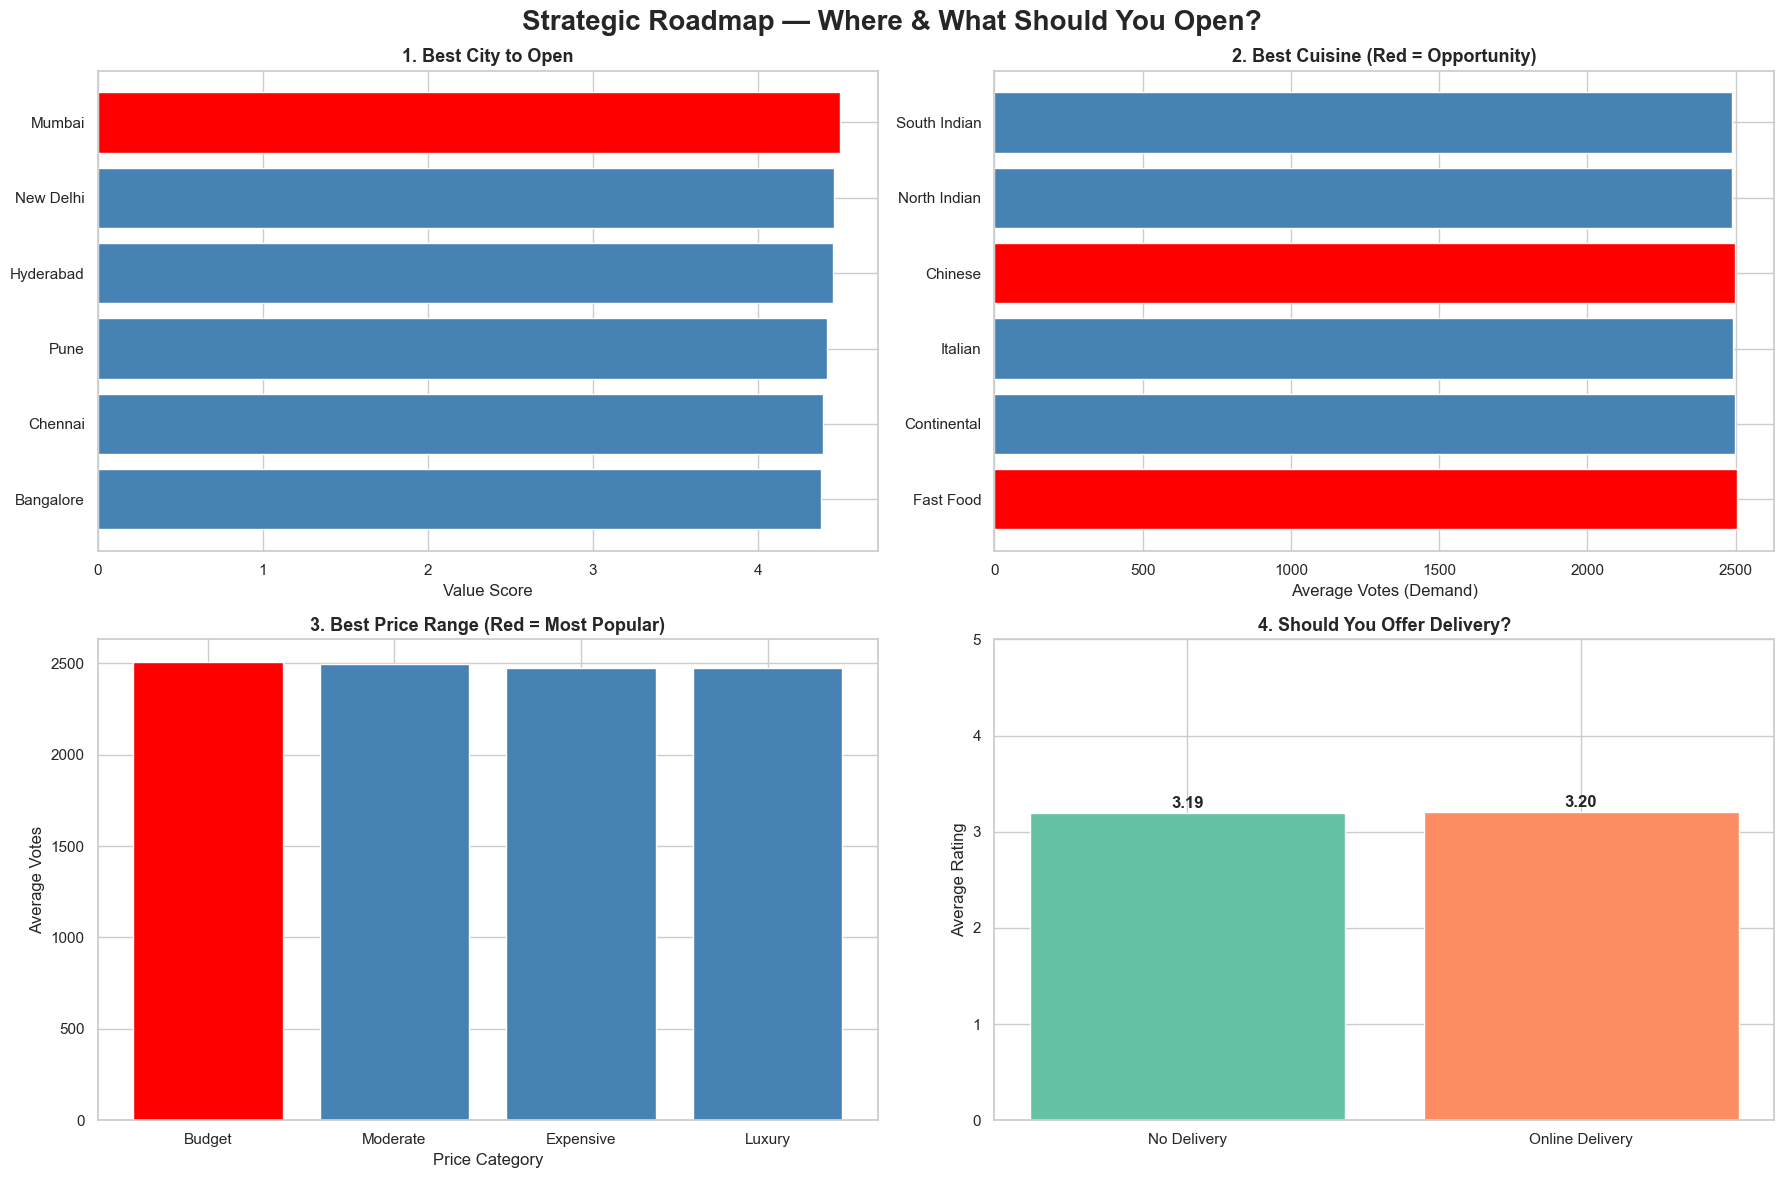


=== FINAL STRATEGIC ROADMAP ===
1. CITY    : Open in MUMBAI
             Highest value score (4.50) — best rating at lowest cost
2. CUISINE : Serve FAST FOOD or CHINESE
             Highest demand but lowest ratings = biggest opportunity gap
3. PRICING : Keep it BUDGET to MODERATE (Price Range 1-2)
             Most votes and footfall in this range
4. DELIVERY: YES — Offer Online Delivery
             12,339 restaurants do it — customers expect it
5. FOCUS ON: FOOD QUALITY above everything else
             Neither price nor delivery significantly affects ratings
             Quality is the only true differentiator!



In [79]:
# Phase 5 - Final Deliverable: Strategic Roadmap

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Plot 1: Best City (Value Score) ---
# calculating value score for each city — same formula from phase 4
city_stats = df.groupby('City').agg(
    Avg_Rating=('Aggregate_Rating', 'mean'),
    Avg_Cost=('Average_Cost_for_two', 'mean'),
    Restaurant_Count=('Restaurant_ID', 'count')
).reset_index()
city_stats['Value_Score'] = city_stats['Avg_Rating'] / city_stats['Avg_Cost'] * 1000
city_stats_sorted = city_stats.sort_values('Value_Score', ascending=True)

# highlighting the best city in red so it stands out immediately
colors1 = ['red' if c == city_stats_sorted.iloc[-1]['City']
           else 'steelblue' for c in city_stats_sorted['City']]
axes[0,0].barh(city_stats_sorted['City'], city_stats_sorted['Value_Score'], color=colors1)
axes[0,0].set_title("1. Best City to Open", fontsize=13, fontweight='bold')
axes[0,0].set_xlabel("Value Score")

# --- Plot 2: Best Cuisine (Opportunity Zone) ---
# filtering to top 10 cuisines by count to keep it clean
cuisine_stats = df.groupby('Cuisines').agg(
    Avg_Rating=('Aggregate_Rating', 'mean'),
    Avg_Votes=('Votes', 'mean'),
    Restaurant_Count=('Restaurant_ID', 'count')
).reset_index()
cuisine_stats = cuisine_stats.nlargest(10, 'Restaurant_Count')
avg_votes = cuisine_stats['Avg_Votes'].mean()
avg_rating = cuisine_stats['Avg_Rating'].mean()

# opportunity = high demand but low rating, meaning customers want it but arent satisfied yet
cuisine_stats['Opportunity'] = (
    (cuisine_stats['Avg_Votes'] > avg_votes) &
    (cuisine_stats['Avg_Rating'] < avg_rating)
)
colors2 = ['red' if o else 'steelblue' for o in cuisine_stats['Opportunity']]
axes[0,1].barh(cuisine_stats['Cuisines'], cuisine_stats['Avg_Votes'], color=colors2)
axes[0,1].set_title("2. Best Cuisine (Red = Opportunity)", fontsize=13, fontweight='bold')
axes[0,1].set_xlabel("Average Votes (Demand)")

# --- Plot 3: Best Price Range ---
# checking which price range gets the most votes (footfall)
price_stats = df.groupby('Price_Range').agg(
    Avg_Rating=('Aggregate_Rating', 'mean'),
    Avg_Votes=('Votes', 'mean')
).reset_index()
price_stats['Price_Label'] = ['Budget', 'Moderate', 'Expensive', 'Luxury']

# highlighting the most popular price range in red
colors3 = ['red' if v == price_stats['Avg_Votes'].max()
           else 'steelblue' for v in price_stats['Avg_Votes']]
axes[1,0].bar(price_stats['Price_Label'], price_stats['Avg_Votes'], color=colors3)
axes[1,0].set_title("3. Best Price Range (Red = Most Popular)", fontsize=13, fontweight='bold')
axes[1,0].set_xlabel("Price Category")
axes[1,0].set_ylabel("Average Votes")

# --- Plot 4: Online Delivery Impact ---
# simple comparison — do restaurants with delivery get better ratings?
delivery_stats = df.groupby('Has_Online_delivery')['Aggregate_Rating'].mean()
colors4 = sns.color_palette("Set2", 2)
axes[1,1].bar(['No Delivery', 'Online Delivery'], delivery_stats.values, color=colors4)
axes[1,1].set_title("4. Should You Offer Delivery?", fontsize=13, fontweight='bold')
axes[1,1].set_ylabel("Average Rating")
axes[1,1].set_ylim(0, 5)

# adding the actual rating number on top of each bar
for i, val in enumerate(delivery_stats.values):
    axes[1,1].text(i, val + 0.05, f'{val:.2f}', ha='center',
                   fontsize=12, fontweight='bold')

plt.suptitle("Strategic Roadmap — Where & What Should You Open?",
             fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# final summary of everything we found across all 5 phases
print("""
=== FINAL STRATEGIC ROADMAP ===
1. CITY    : Open in MUMBAI
             Highest value score (4.50) — best rating at lowest cost
2. CUISINE : Serve FAST FOOD or CHINESE
             Highest demand but lowest ratings = biggest opportunity gap
3. PRICING : Keep it BUDGET to MODERATE (Price Range 1-2)
             Most votes and footfall in this range
4. DELIVERY: YES — Offer Online Delivery
             12,339 restaurants do it — customers expect it
5. FOCUS ON: FOOD QUALITY above everything else
             Neither price nor delivery significantly affects ratings
             Quality is the only true differentiator!
""")